# Candidate Test 2022 Analysis Part 2

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2). Consider normalizing the data or performing similar scaling transformations as needed.

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:

- An analysis/description of which questions are most crucial concerning their placement on the axes.
- Average positions of parties concerning each question, preferably with accompanying plots of each (or selected) question.
- A clustering analysis where you attempt various cluster numbers, which would correspond to different parties. Discuss whether there is room for more clusters/parties or if a reduction is needed. Make sure you cover: **K-Means, Hierarchical clustering, and DBSCAN.**
- An overview of the political landscape of the elected candidates, highlighting which members agree or disagree the most and which parties or party members have significant disagreements.
- Feel free to explore further and remember that preprocessing, methodology, and evaluation metrics are not mentioned explicitly, but are implicitly assumed.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



In [8]:
# Import libraries
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
# Load raw candidate response data from alldata.xlsx
raw_data = pd.read_excel('alldata.xlsx')

# Display the first few rows for inspection
display(raw_data.head())

# Define party colors for consistent plotting
party_colors = {
    "Socialdemokratiet": "#b32722",
    "Radikale Venstre": "#713280",
    "Det Konservative Folkeparti": "#9eba27",
    "Nye Borgerlige": "#054f5c",
    "Socialistisk Folkeparti": "#dd0878",
    "Liberal Alliance": "#21c6cf",
    "Kristendemokraterne": "#bababa",
    "Moderaterne": "#6c39e5",
    "Dansk Folkeparti": "#f3cd41",
    "Frie Grønne, Danmarks Nye Venstrefløjsparti": "#00e66a",
    "Venstre": "#006697",
    "Danmarksdemokraterne": "#8ac3ff",
    "Enhedslisten": "#ed8019",
    "Alternativet": "#2a8f39",
    "Løsgænger": "#8c564b"
}

# Define question columns and readable labels for plotting
question_columns = [
    '1a', '1b', '530', '546', '559', '561', '7a', '7b', '4a', '4b',
    '531', '541', '545', '550', '556', '8a', '8b', '9a', '9b', '538',
    '553', '5a', '5b', '537', '540', '543', '548', '557', '2a', '2b',
    '552', '563', '544', '547', '533', '534', '535', '551', '555',
    '3a', '3b', '6a', '6b', '10a', '10b', '11a', '11b', '12a', '12b'
]

question_labels = [
    '1a [Miljø/Klima]', '1b [Miljø/Klima]', '530 [Miljø/Klima]', '546 [Klima/Energi]', '559 [Klima/Energi]', '561 [Klima/Energi]',
    '7a [Energi]', '7b [Energi]', '4a [Økonomi]', '4b [Økonomi]', '531 [Arbejdsmarked/Økonomi]', '541 [Arbejdsmarked/Økonomi]',
    '545 [Arbejdsmarked/Økonomi]', '550 [Arbejdsmarked/Økonomi]', '556 [Arbejdsmarked/Økonomi]', '8a [Børn/Unge]', '8b [Børn/Unge]',
    '9a [Skole/Uddannelse]', '9b [Skole/Uddannelse]', '538 [Uddannelse]', '553 [Uddannelse]', '5a [Ældre]', '5b [Ældre]',
    '537 [Velfærd]', '540 [Velfærd]', '543 [Velfærd]', '548 [Velfærd]', '557 [Velfærd]', '2a [Hospice/Sundhed]', '2b [Hospice/Sundhed]',
    '552 [Sundhed]', '563 [Sundhed]', '544 [Demokrati]', '547 [Demokrati]', '533 [Ret/Straf]', '534 [EU/Udenrigs]', '535 [EU/Udenrigs]',
    '551 [EU/Udenrigs]', '555 [EU/Udenrigs]', '3a [Udenrigs/Forsvarspolitik]', '3b [Udenrigs/Forsvarspolitik]',
    '6a [Flygtninge/Indvandring]', '6b [Flygtninge/Indvandring]', '10a [Social]', '10b [Social]', '11a [Mink-Sagen]',
    '11b [Mink-Sagen]', '12a [Coronavirus]', '12b [Coronavirus]'
]

,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,0,1,-2,-2,1,1,1,Københavns Storkreds,78
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,-1,-2,0,2,0,-1,1,-2,Bornholms Storkreds,37
3,2,1,-2,-1,1,1,1,1,1,-2,...,-2,2,2,2,2,-1,2,0,Nordjyllands Storkreds,28
4,1,1,-2,2,-2,1,-2,1,2,-2,...,-2,0,-1,0,-2,0,2,-2,Københavns Storkreds,58


C:\Users\DooMz\AppData\Local\Temp\ipykernel_1332\4076217969.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=variances.head(15).index, y=variances.head(15).values, palette='viridis')


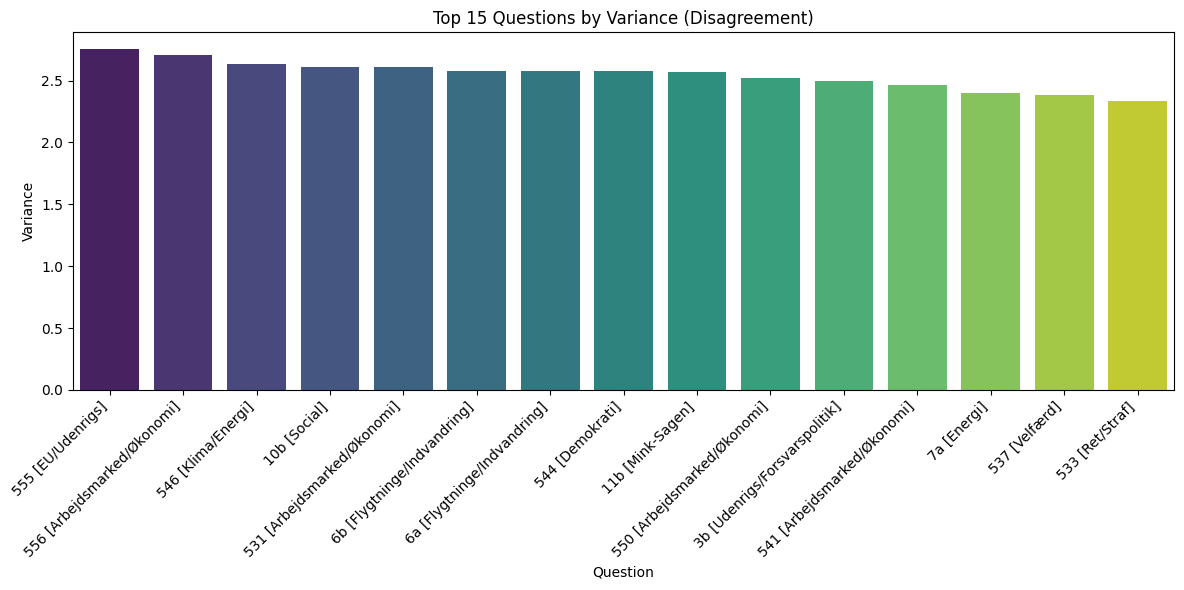

Top 10 questions influencing PC1 (likely left-right axis):


,PC1
530 [Miljø/Klima],0.190641
537 [Velfærd],-0.190284
4a [Økonomi],0.188849
3b [Udenrigs/Forsvarspolitik],0.188778
550 [Arbejdsmarked/Økonomi],0.188555
531 [Arbejdsmarked/Økonomi],0.187016
543 [Velfærd],-0.185893
548 [Velfærd],0.176281
559 [Klima/Energi],0.176279
540 [Velfærd],-0.174404



Top 10 questions influencing PC2 (likely second ideological dimension):


,PC2
10b [Social],0.302918
556 [Arbejdsmarked/Økonomi],-0.297979
551 [EU/Udenrigs],0.293836
553 [Uddannelse],0.272808
4b [Økonomi],0.258449
5a [Ældre],-0.228295
6a [Flygtninge/Indvandring],-0.208142
6b [Flygtninge/Indvandring],0.207708
555 [EU/Udenrigs],0.206750
534 [EU/Udenrigs],0.201447


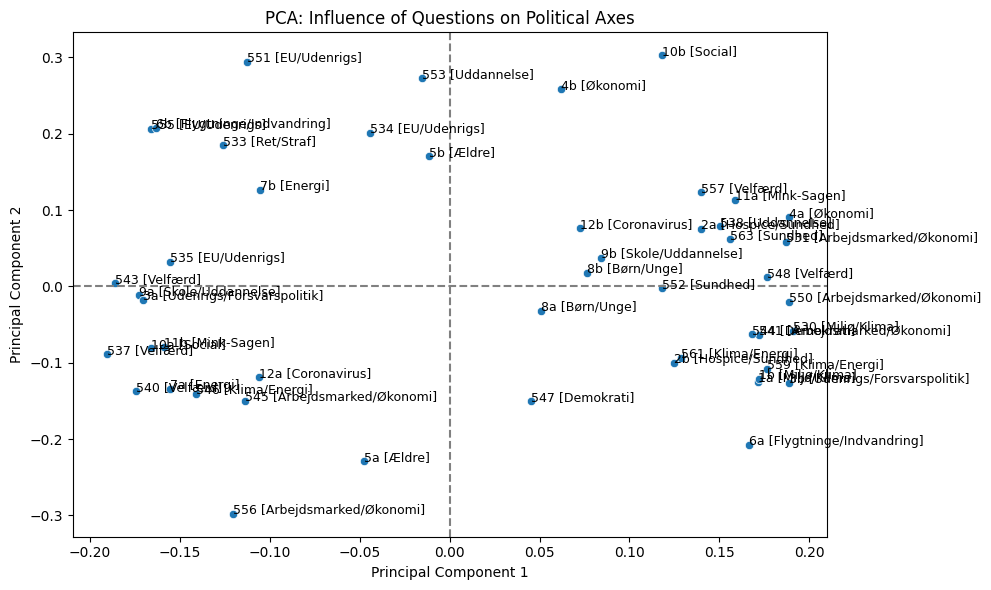

In [10]:
#Data Analysis: An analysis/description of which questions are most crucial concerning their placement on the axes.

# Link labels to data
label_map = dict(zip(question_columns, question_labels))

# 🎯 1. Variance-based importance
variances = raw_data[question_columns].var()
variances.index = [label_map[col] for col in variances.index]
variances = variances.sort_values(ascending=False)

# 📈 Plot top 15 most variable questions
plt.figure(figsize=(12, 6))
sns.barplot(x=variances.head(15).index, y=variances.head(15).values, palette='viridis')
plt.title('Top 15 Questions by Variance (Disagreement)')
plt.ylabel('Variance')
plt.xlabel('Question')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 🎯 2. PCA: Principal Components to determine axis-driving questions
scaler = StandardScaler()
X_scaled = scaler.fit_transform(raw_data[question_columns])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

loadings = pd.DataFrame(pca.components_.T, index=[label_map[col] for col in question_columns], columns=['PC1', 'PC2'])
loadings['PC1_abs'] = loadings['PC1'].abs()
loadings['PC2_abs'] = loadings['PC2'].abs()

# 🔍 Print top contributors
print("Top 10 questions influencing PC1 (likely left-right axis):")
display(loadings.sort_values('PC1_abs', ascending=False).head(10)[['PC1']])

print("\nTop 10 questions influencing PC2 (likely second ideological dimension):")
display(loadings.sort_values('PC2_abs', ascending=False).head(10)[['PC2']])

# 🧭 Visualize loading plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', data=loadings)
for i in loadings.index:
    plt.text(loadings.loc[i, 'PC1'], loadings.loc[i, 'PC2'], i, fontsize=9)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.title('PCA: Influence of Questions on Political Axes')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()